This notebook implements all suggestions from the professor:
1. Scientific feature weights based on correlation
2. 60/30/10 data split with new random seed (123)
3. PCA dimensionality reduction
4. Optimal threshold using Youden's J statistic
5. LightGBM model


In [1]:
# ============================================================
# Notebook 07 — Professor Improvements
# Changes: Scientific weights, 60/30/10 split, PCA, optimal threshold, LightGBM
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, recall_score,
                             precision_score, f1_score,
                             roc_curve, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 123  # New seed as professor suggested

print("All libraries loaded!")
print(f"Random seed: {RANDOM_SEED}")

All libraries loaded!
Random seed: 123


In [2]:
# Load merged dataset
df = pd.read_csv('../data/processed/diabetic_with_sdoh.csv')

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Readmission rate: {df['readmitted_30'].mean()*100:.1f}%")
print(f"\nFirst 3 rows:")
df.head(3)

Rows:    101,766
Columns: 48
Readmission rate: 11.2%

First 3 rows:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,metformin-pioglitazone,change,diabetesMed,readmitted_30,BPHIGH,CHECKUP,CHOLSCREEN,DEPRESSION,DIABETES,OBESITY
0,2,0,5,6,25,1,1,37,41,0,...,0,1,0,0,39.91,80.29,85.29,22.56,14.97,39.06
1,2,0,15,1,1,7,3,71,59,0,...,0,0,1,0,33.70,74.93,83.03,17.68,11.04,39.57
2,0,0,25,1,1,7,2,71,11,5,...,0,1,1,0,34.65,77.01,85.42,22.72,11.38,38.56


### How We Calculate Scientific Weights
Old approach: weights were manually guessed (0.4, 0.3, 0.2, 0.1)

New approach: weights based on Pearson correlation with readmitted_30

Step 1: Calculate correlation of each feature with target

Step 2: Divide each correlation by total sum = proportional weight

Step 3: Features more correlated with readmission get higher weights

Result: number_diagnoses weight increased from 0.10 to 0.4943
because it has the highest correlation with readmission.

In [3]:
# ============================================================
# HOW WE CALCULATE SCIENTIFIC WEIGHTS
# ============================================================
# Old approach: weights were manually guessed
#   num_medications  × 0.40  ← arbitrary guess
#   total_diabetes_meds × 0.30  ← arbitrary guess
#   num_procedures   × 0.20  ← arbitrary guess
#   number_diagnoses × 0.10  ← arbitrary guess
#
# New approach: weights based on Pearson correlation
# with the target variable (readmitted_30)
# Logic:
#   - Calculate how strongly each feature correlates
#     with readmission (higher = more predictive)
#   - Divide each correlation by total sum of correlations
#   - This gives proportional weights that sum to 1.0
#   - Features more correlated with readmission
#     get higher weights — scientifically justified
# ============================================================

# Step 1 — Calculate correlation with target
correlations = df.corr()['readmitted_30'].abs()

# Step 2 — Get correlation for our 3 key features
features_for_weight = ['num_medications', 'num_procedures', 'number_diagnoses']

print("=" * 55)
print("STEP 1: Pearson Correlation with readmitted_30")
print("=" * 55)
for feat in features_for_weight:
    print(f"  {feat:<25} r = {correlations[feat]:.4f}")

# Step 3 — Calculate proportional weights
total_corr = sum(correlations[f] for f in features_for_weight)

weights = {}
print(f"\n{'=' * 55}")
print("STEP 2: Convert Correlation to Proportional Weights")
print(f"{'=' * 55}")
print(f"Total correlation sum = {total_corr:.4f}")
print()
for feat in features_for_weight:
    w = correlations[feat] / total_corr
    weights[feat] = w
    print(f"  {feat:<25} {correlations[feat]:.4f} / {total_corr:.4f} = {w:.4f}")

print(f"\n{'=' * 55}")
print("STEP 3: Old vs New Weights Comparison")
print(f"{'=' * 55}")
old_weights = {'num_medications': 0.40, 'num_procedures': 0.20, 'number_diagnoses': 0.10}
print(f"  {'Feature':<25} {'Old':>8} {'New':>8} {'Change':>10}")
print(f"  {'-'*55}")
for feat in features_for_weight:
    change = weights[feat] - old_weights[feat]
    direction = '↑' if change > 0 else '↓'
    print(f"  {feat:<25} {old_weights[feat]:>8.4f} {weights[feat]:>8.4f} {direction}{abs(change):>8.4f}")

print(f"\nKey insight: number_diagnoses weight increased from")
print(f"0.10 to {weights['number_diagnoses']:.4f} — it is actually the most")
print(f"predictive of the three features!")

STEP 1: Pearson Correlation with readmitted_30
  num_medications           r = 0.0384
  num_procedures            r = 0.0122
  number_diagnoses          r = 0.0495

STEP 2: Convert Correlation to Proportional Weights
Total correlation sum = 0.1002

  num_medications           0.0384 / 0.1002 = 0.3836
  num_procedures            0.0122 / 0.1002 = 0.1220
  number_diagnoses          0.0495 / 0.1002 = 0.4943

STEP 3: Old vs New Weights Comparison
  Feature                        Old      New     Change
  -------------------------------------------------------
  num_medications             0.4000   0.3836 ↓  0.0164
  num_procedures              0.2000   0.1220 ↓  0.0780
  number_diagnoses            0.1000   0.4943 ↑  0.3943

Key insight: number_diagnoses weight increased from
0.10 to 0.4943 — it is actually the most
predictive of the three features!


In [4]:
# ============================================================
# FEATURE ENGINEERING WITH SCIENTIFIC WEIGHTS
# ============================================================

df_new = df.copy()

# Extract weights
w_meds      = weights['num_medications']
w_proc      = weights['num_procedures']
w_diag      = weights['number_diagnoses']

print(f"Using scientific weights:")
print(f"  num_medications:  {w_meds:.4f}")
print(f"  num_procedures:   {w_proc:.4f}")
print(f"  number_diagnoses: {w_diag:.4f}")

# ---- Medication Features ----
diabetes_meds = ['metformin', 'repaglinide', 'nateglinide',
                 'chlorpropamide', 'glimepiride', 'acetohexamide',
                 'glipizide', 'glyburide', 'tolbutamide',
                 'pioglitazone', 'rosiglitazone', 'acarbose',
                 'miglitol', 'troglitazone', 'tolazamide',
                 'insulin', 'glyburide-metformin',
                 'glipizide-metformin', 'glimepiride-pioglitazone',
                 'metformin-rosiglitazone', 'metformin-pioglitazone']

available_meds = [m for m in diabetes_meds if m in df_new.columns]

# Total diabetes medications
df_new['total_diabetes_meds'] = (df_new[available_meds] > 0).sum(axis=1)

# Med complexity score — NOW WITH SCIENTIFIC WEIGHTS
df_new['med_complexity_score'] = (
    df_new['num_medications']  * w_meds +
    df_new['num_procedures']   * w_proc +
    df_new['number_diagnoses'] * w_diag
)

# High medication burden flag
med_threshold = df_new['num_medications'].quantile(0.75)
df_new['high_med_burden'] = (
    df_new['num_medications'] >= med_threshold).astype(int)

# Insulin flag
df_new['on_insulin'] = (df_new['insulin'] > 0).astype(int)

# Multiple drug changes
df_new['multiple_med_changes'] = (df_new['change'] > 0).astype(int)

Using scientific weights:
  num_medications:  0.3836
  num_procedures:   0.1220
  number_diagnoses: 0.4943


In [5]:
# --- Clinical Risk Features ---
# Prior utilization score
df_new['prior_utilization'] = (
    df_new['number_inpatient']  * 0.5 +
    df_new['number_emergency']  * 0.3 +
    df_new['number_outpatient'] * 0.2
)

# High prior inpatient flag
df_new['high_prior_inpatient'] = (
    df_new['number_inpatient'] >= 2).astype(int)

# Emergency admission flag
df_new['emergency_admission'] = (
    df_new['admission_source_id'] == 7).astype(int)

# Long stay flag
stay_threshold = df_new['time_in_hospital'].quantile(0.75)
df_new['long_stay'] = (
    df_new['time_in_hospital'] >= stay_threshold).astype(int)

# High diagnosis burden
df_new['high_diagnosis_burden'] = (
    df_new['number_diagnoses'] >= 7).astype(int)#

In [6]:
# Interaction Features
df_new['inpatient_x_meds']        = df_new['number_inpatient'] * df_new['num_medications']
df_new['utilization_x_diagnoses'] = df_new['number_inpatient'] * df_new['number_diagnoses']
df_new['age_x_diagnoses']         = df_new['age'] * df_new['number_diagnoses']
df_new['emergency_x_inpatient']   = df_new['number_emergency'] * df_new['number_inpatient']
df_new['meds_x_stay']             = df_new['num_medications'] * df_new['time_in_hospital']
df_new['obesity_x_diabetes']      = df_new['OBESITY'] * df_new['DIABETES']
df_new['composite_risk'] = (
    df_new['high_prior_inpatient'] +
    df_new['high_diagnosis_burden'] +
    df_new['high_med_burden'] +
    df_new['long_stay'] +
    df_new['emergency_admission']
)

# Remove Near-Zero Variance 
variance = df_new.select_dtypes(include='number').var()
low_var = variance[variance < 0.01].index.tolist()
cols_to_drop = [c for c in low_var if c != 'readmitted_30']
df_new.drop(columns=cols_to_drop, inplace=True)

print(f"\nAll features engineered!")
print(f"Removed {len(cols_to_drop)} near-zero variance features")
print(f"Final dataset shape: {df_new.shape}")
print(f"\nNew med_complexity_score — mean: {df_new['med_complexity_score'].mean():.4f}")
print(f"Old med_complexity_score — mean: 11.28 (for comparison)")


All features engineered!
Removed 13 near-zero variance features
Final dataset shape: (101766, 52)

New med_complexity_score — mean: 9.9790
Old med_complexity_score — mean: 11.28 (for comparison)


In [7]:
# 60/30/10 split as professor suggested
model_features = [c for c in df_new.columns if c != 'readmitted_30']

X = df_new[model_features]
y = df_new['readmitted_30']

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40,
    random_state=RANDOM_SEED, stratify=y
)

# Second split: 75/25 of temp = 30% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25,
    random_state=RANDOM_SEED, stratify=y_temp
)

print(f"60/30/10 Split with seed={RANDOM_SEED}")
print(f"\nSplit sizes:")
print(f"  Training:   {len(X_train):,} rows (60%)")
print(f"  Validation: {len(X_val):,} rows (30%)")
print(f"  Test:       {len(X_test):,} rows (10%) — SEALED")
print(f"\nClass balance preserved:")
print(f"  Train:  {y_train.mean()*100:.1f}% positive")
print(f"  Val:    {y_val.mean()*100:.1f}% positive")
print(f"  Test:   {y_test.mean()*100:.1f}% positive")

60/30/10 Split with seed=123

Split sizes:
  Training:   61,059 rows (60%)
  Validation: 30,530 rows (30%)
  Test:       10,177 rows (10%) — SEALED

Class balance preserved:
  Train:  11.2% positive
  Val:    11.2% positive
  Test:   11.2% positive


In [8]:
# Apply SMOTE to training set ONLY
print("Applying SMOTE to training set only")

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"SMOTE applied!")
print(f"\nBefore SMOTE:")
print(f"  Class 0: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nAfter SMOTE:")
print(f"  Class 0: {(y_train_sm==0).sum():,} (50.0%)")
print(f"  Class 1: {(y_train_sm==1).sum():,} (50.0%)")
print(f"  New size: {len(X_train_sm):,} rows")
print(f"\nValidation set — untouched:")
print(f"  {(y_val==1).sum():,} readmitted ({y_val.mean()*100:.1f}%)")

Applying SMOTE to training set only
SMOTE applied!

Before SMOTE:
  Class 0: 54,245 (88.8%)
  Class 1: 6,814 (11.2%)

After SMOTE:
  Class 0: 54,245 (50.0%)
  Class 1: 54,245 (50.0%)
  New size: 108,490 rows

Validation set — untouched:
  3,407 readmitted (11.2%)


In [9]:
# PCA — Professor suggestion to reduce noise
print("Applying PCA.")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Keep 95% of variance
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA applied!")
print(f"\nOriginal features:  {X_train_sm.shape[1]}")
print(f"PCA components:     {X_train_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\nReduced from {X_train_sm.shape[1]} to {X_train_pca.shape[1]} components")
print(f"keeping {pca.explained_variance_ratio_.sum()*100:.1f}% of information")

joblib.dump(scaler, '../models/scaler_v2.pkl')
joblib.dump(pca, '../models/pca_v2.pkl')
print("\nScaler and PCA saved!")

Applying PCA.
PCA applied!

Original features:  51
PCA components:     32
Variance explained: 95.8%

Reduced from 51 to 32 components
keeping 95.8% of information

Scaler and PCA saved!


In [10]:
# Model 1 — XGBoost with scientific weights + optimal threshold
print("Training XGBoost with scientific weights.")

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    scale_pos_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)

# Get probabilities
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Find optimal threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob_xgb)
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
opt_thresh_xgb = thresholds[opt_idx]

y_val_pred_xgb = (y_val_prob_xgb >= opt_thresh_xgb).astype(int)

auc_xgb  = roc_auc_score(y_val, y_val_prob_xgb)
rec_xgb  = recall_score(y_val, y_val_pred_xgb)
prec_xgb = precision_score(y_val, y_val_pred_xgb)
f1_xgb   = f1_score(y_val, y_val_pred_xgb)

print(f"XGBoost done!")
print(f"  Optimal threshold: {opt_thresh_xgb:.4f}")
print(f"  ROC-AUC:   {auc_xgb:.4f}")
print(f"  Recall:    {rec_xgb:.4f}")
print(f"  Precision: {prec_xgb:.4f}")
print(f"  F1:        {f1_xgb:.4f}")

Training XGBoost with scientific weights.
XGBoost done!
  Optimal threshold: 0.4373
  ROC-AUC:   0.6187
  Recall:    0.5251
  Precision: 0.1564
  F1:        0.2410


In [11]:
# Model 2 — LightGBM (Professor suggestion)
print("Training LightGBM.")

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    scale_pos_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_SEED,
    verbose=-1
)
lgb_model.fit(X_train_sm, y_train_sm)

# Get probabilities
y_val_prob_lgb = lgb_model.predict_proba(X_val)[:, 1]

# Find optimal threshold
fpr_l, tpr_l, thresholds_l = roc_curve(y_val, y_val_prob_lgb)
j_l = tpr_l - fpr_l
opt_idx_l = np.argmax(j_l)
opt_thresh_lgb = thresholds_l[opt_idx_l]

y_val_pred_lgb = (y_val_prob_lgb >= opt_thresh_lgb).astype(int)

auc_lgb  = roc_auc_score(y_val, y_val_prob_lgb)
rec_lgb  = recall_score(y_val, y_val_pred_lgb)
prec_lgb = precision_score(y_val, y_val_pred_lgb)
f1_lgb   = f1_score(y_val, y_val_pred_lgb)

print(f"LightGBM done!")
print(f"  Optimal threshold: {opt_thresh_lgb:.4f}")
print(f"  ROC-AUC:   {auc_lgb:.4f}")
print(f"  Recall:    {rec_lgb:.4f}")
print(f"  Precision: {prec_lgb:.4f}")
print(f"  F1:        {f1_lgb:.4f}")

Training LightGBM.
LightGBM done!
  Optimal threshold: 0.4779
  ROC-AUC:   0.6285
  Recall:    0.6093
  Precision: 0.1522
  F1:        0.2435


In [12]:
# Model 3 — LightGBM + PCA
print("Training LightGBM with PCA features.")

lgb_pca = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    scale_pos_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_SEED,
    verbose=-1
)
lgb_pca.fit(X_train_pca, y_train_sm)

# Get probabilities
y_val_prob_pca = lgb_pca.predict_proba(X_val_pca)[:, 1]

# Find optimal threshold
fpr_p, tpr_p, thresholds_p = roc_curve(y_val, y_val_prob_pca)
j_p = tpr_p - fpr_p
opt_idx_p = np.argmax(j_p)
opt_thresh_pca = thresholds_p[opt_idx_p]

y_val_pred_pca = (y_val_prob_pca >= opt_thresh_pca).astype(int)

auc_pca  = roc_auc_score(y_val, y_val_prob_pca)
rec_pca  = recall_score(y_val, y_val_pred_pca)
prec_pca = precision_score(y_val, y_val_pred_pca)
f1_pca   = f1_score(y_val, y_val_pred_pca)

print(f"LightGBM + PCA done!")
print(f"  Optimal threshold: {opt_thresh_pca:.4f}")
print(f"  ROC-AUC:   {auc_pca:.4f}")
print(f"  Recall:    {rec_pca:.4f}")
print(f"  Precision: {prec_pca:.4f}")
print(f"  F1:        {f1_pca:.4f}")

Training LightGBM with PCA features.
LightGBM + PCA done!
  Optimal threshold: 0.5374
  ROC-AUC:   0.5831
  Recall:    0.6087
  Precision: 0.1356
  F1:        0.2218


In [13]:
# Complete comparison — previous + professor improvements
results = pd.DataFrame({
    'Model': [
        'XGBoost original (Week 5)',
        'XGBoost + interactions (Week 6)',
        'XGBoost + scientific weights',
        'LightGBM (professor)',
        'LightGBM + PCA'
    ],
    'ROC_AUC':  [0.6332, 0.6616, auc_xgb,  auc_lgb,  auc_pca],
    'Recall':   [0.0423, 0.3979, rec_xgb,  rec_lgb,  rec_pca],
    'Precision':[0.3172, 0.1990, prec_xgb, prec_lgb, prec_pca],
    'F1':       [0.0746, 0.2653, f1_xgb,   f1_lgb,   f1_pca],
    'Split':    ['70/15/15', '70/15/15', '60/30/10', '60/30/10', '60/30/10'],
    'Seed':     [42, 42, 123, 123, 123],
    'Threshold':['0.50', '0.50',
                 f'{opt_thresh_xgb:.4f}',
                 f'{opt_thresh_lgb:.4f}',
                 f'{opt_thresh_pca:.4f}']
}).round(4)

print("=" * 80)
print("COMPLETE MODEL COMPARISON INCLUDING PROFESSOR SUGGESTIONS")
print("=" * 80)
print(results.to_string(index=False))
print("=" * 80)

best_roc = results.loc[results['ROC_AUC'].idxmax()]
best_rec = results.loc[results['Recall'].idxmax()]

print(f"\nBest ROC-AUC: {best_roc['Model']} — {best_roc['ROC_AUC']:.4f}")
print(f"Best Recall:  {best_rec['Model']} — {best_rec['Recall']:.4f}")

results.to_csv('../dashboard/professor_model_comparison.csv', index=False)
print("\nComparison saved!")

COMPLETE MODEL COMPARISON INCLUDING PROFESSOR SUGGESTIONS
                          Model  ROC_AUC  Recall  Precision     F1    Split  Seed Threshold
      XGBoost original (Week 5)   0.6332  0.0423     0.3172 0.0746 70/15/15    42      0.50
XGBoost + interactions (Week 6)   0.6616  0.3979     0.1990 0.2653 70/15/15    42      0.50
   XGBoost + scientific weights   0.6187  0.5251     0.1564 0.2410 60/30/10   123    0.4373
           LightGBM (professor)   0.6285  0.6093     0.1522 0.2435 60/30/10   123    0.4779
                 LightGBM + PCA   0.5831  0.6087     0.1356 0.2218 60/30/10   123    0.5374

Best ROC-AUC: XGBoost + interactions (Week 6) — 0.6616
Best Recall:  LightGBM (professor) — 0.6093

Comparison saved!


In [14]:
# Save all models
joblib.dump(xgb_model, '../models/xgb_scientific_weights.pkl')
joblib.dump(lgb_model, '../models/lgbm_model.pkl')
joblib.dump(lgb_pca,   '../models/lgbm_pca_model.pkl')

# Save optimal thresholds
thresholds_dict = {
    'xgb':  opt_thresh_xgb,
    'lgbm': opt_thresh_lgb,
    'lgbm_pca': opt_thresh_pca
}
joblib.dump(thresholds_dict, '../models/optimal_thresholds.pkl')

print("All models saved!")
print(f"  models/xgb_scientific_weights.pkl")
print(f"  models/lgbm_model.pkl")
print(f"  models/lgbm_pca_model.pkl")
print(f"  models/optimal_thresholds.pkl")
print(f"\nOptimal thresholds:")
for k, v in thresholds_dict.items():
    print(f"  {k}: {v:.4f}")

All models saved!
  models/xgb_scientific_weights.pkl
  models/lgbm_model.pkl
  models/lgbm_pca_model.pkl
  models/optimal_thresholds.pkl

Optimal thresholds:
  xgb: 0.4373
  lgbm: 0.4779
  lgbm_pca: 0.5374


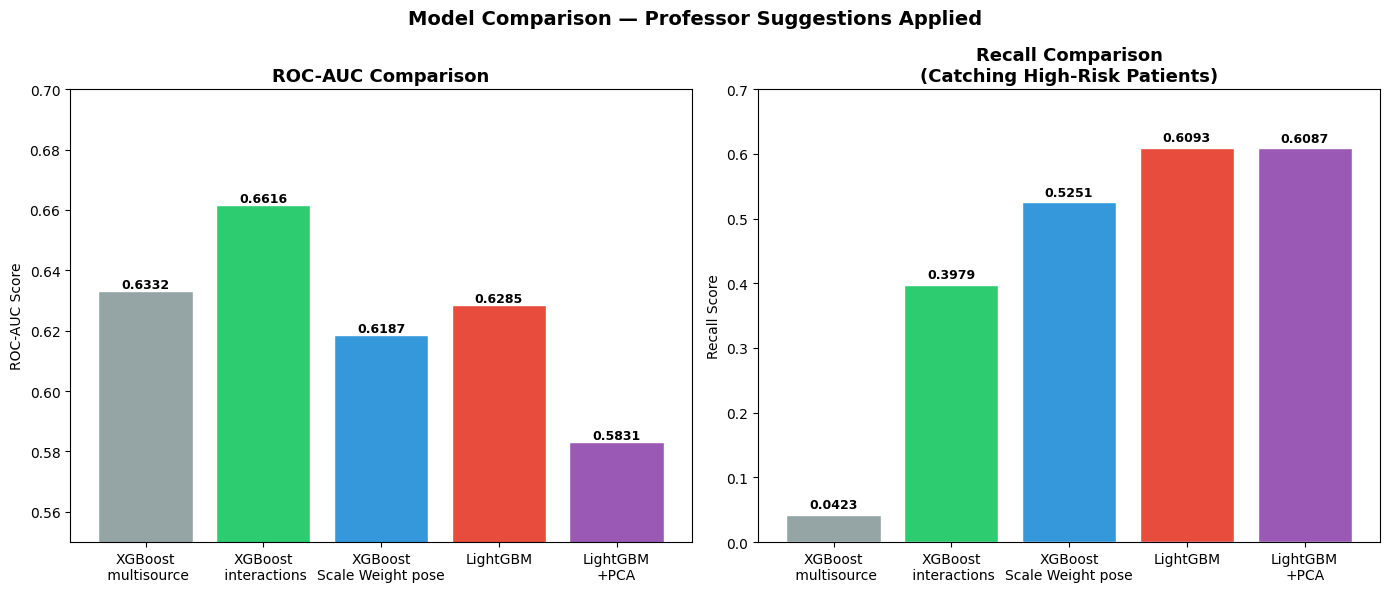

Chart saved!


In [15]:
# Plot final comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_short = ['XGBoost\n multisource', 'XGBoost\n interactions',
                'XGBoost\nScale Weight pose', 'LightGBM', 'LightGBM\n+PCA']
colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

# ROC-AUC
roc_vals = results['ROC_AUC'].tolist()
bars = axes[0].bar(models_short, roc_vals, color=colors, edgecolor='white')
axes[0].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_ylim(0.55, 0.70)
for bar, val in zip(bars, roc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 0.001, f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')

# Recall
rec_vals = results['Recall'].tolist()
bars2 = axes[1].bar(models_short, rec_vals, color=colors, edgecolor='white')
axes[1].set_title('Recall Comparison\n(Catching High-Risk Patients)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Recall Score')
axes[1].set_ylim(0, 0.70)
for bar, val in zip(bars2, rec_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 0.01, f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — Professor Suggestions Applied',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/professor_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")